# 03 分析与可视化 (Analysis & Visualization)

**课程**: 数据分析  
**姓名**: 廖婉琼  
**学号**: 25210178  

---

本 Notebook 完成以下分析任务：
1. 基本统计量表格（对数收益率 + 行业 + 最大回撤）
2. 图1: 归一化收盘价走势（叠加沪深300，行业分组着色）
3. 图2: 日对数收益率分布（2x5，标注均值标准差）
4. 图3: 相关系数热力图（按行业排序）
5. 图4: 宏观指标与沪深300月度收益率散点图
6. 图5: ROE 对比（选做）
7. CAPM 回归分析（含无风险利率、95%CI、Beta点图）

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import sqlite3
import os
import warnings
warnings.filterwarnings('ignore')

# ============ 中文字体设置 ============
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'KaiTi']
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 150

# ============ 全局图表样式（专业报告规范） ============
TITLE_FS = 14
TITLE_FW = 'bold'
LABEL_FS = 11
TICK_FS = 9
LEGEND_FS = 9
ANNOT_FS = 9
SUB_FS = 12

GRID_CLR = '#D5D8DC'
GRID_ALPHA = 0.6
GRID_LW = 0.5
AX_EDGE = '#BDC3C7'
AX_LW = 0.8
TITLE_CLR = '#2C3E50'
LABEL_CLR = '#34495E'
TICK_CLR = '#5D6D7E'
BG = '#FAFAFA'
FIG_BG = 'white'
BOX_BG = '#F2F3F4'
BOX_EDGE = '#D5D8DC'

DATA_LW = 1.5
BENCH_LW = 2.0
FIT_LW = 1.8
REF_LW = 0.8
MK_SZ = 5
SC_SZ = 60

matplotlib.rcParams.update({
    'axes.facecolor': BG, 'figure.facecolor': FIG_BG,
    'axes.edgecolor': AX_EDGE, 'axes.linewidth': AX_LW,
    'axes.grid': True, 'grid.color': GRID_CLR,
    'grid.alpha': GRID_ALPHA, 'grid.linewidth': GRID_LW,
    'xtick.color': TICK_CLR, 'ytick.color': TICK_CLR,
    'xtick.labelsize': TICK_FS, 'ytick.labelsize': TICK_FS,
    'axes.labelcolor': LABEL_CLR, 'axes.titlecolor': TITLE_CLR,
    'legend.frameon': True, 'legend.framealpha': 0.9,
    'legend.edgecolor': BOX_EDGE, 'legend.fancybox': False,
    'savefig.facecolor': FIG_BG, 'savefig.edgecolor': 'none',
    'savefig.bbox': 'tight',
})

# ============ 路径配置 ============
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, 'data')
CLEAN_DIR = os.path.join(DATA_DIR, 'clean')
COMBINED_DIR = os.path.join(DATA_DIR, 'combined')
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('分析环境初始化完成（全局样式已配置）')

分析环境初始化完成（全局样式已配置）


## 3.0 加载清洗后数据

In [2]:
# ============ 股票配置 ============
stock_config = {
    '002594': {'name': '比亚迪', 'industry': '新能源汽车'},
    '601633': {'name': '长城汽车', 'industry': '新能源汽车'},
    '600519': {'name': '贵州茅台', 'industry': '白酒'},
    '000858': {'name': '五粮液', 'industry': '白酒'},
    '601857': {'name': '中国石油', 'industry': '能源'},
    '601088': {'name': '中国神华', 'industry': '能源'},
    '600941': {'name': '中国移动', 'industry': '通信'},
    '000063': {'name': '中兴通讯', 'industry': '通信'},
    '002352': {'name': '顺丰控股', 'industry': '物流'},
    '600233': {'name': '圆通速递', 'industry': '物流'},
}

stock_names = [v['name'] for v in stock_config.values()]
stock_industry = {v['name']: v['industry'] for v in stock_config.values()}
industries = sorted(set(stock_industry.values()))

# 行业颜色（商务沉稳色系）
industry_colors = {
    '新能源汽车': '#C0392B',
    '白酒': '#7D3C98',
    '能源': '#D4763C',
    '通信': '#2874A6',
    '物流': '#2E86C1',
}

# 每只股票独立颜色（商务沉稳色系）
stock_unique_colors = {
    '比亚迪': '#C0392B',
    '长城汽车': '#D4763C',
    '贵州茅台': '#7D3C98',
    '五粮液': '#2E86C1',
    '中国石油': '#E67E22',
    '中国神华': '#27AE60',
    '中国移动': '#1ABC9C',
    '中兴通讯': '#2874A6',
    '顺丰控股': '#884EA0',
    '圆通速递': '#CA6F1E',
}

print('共 {} 只股票，覆盖 {} 个行业: {}'.format(len(stock_names), len(industries), industries))

共 10 只股票，覆盖 5 个行业: ['新能源汽车', '物流', '白酒', '能源', '通信']


In [3]:
# ============ 从 SQLite 加载数据 ============
db_path = os.path.join(CLEAN_DIR, 'finance.db')
conn = sqlite3.connect(db_path)

code_to_table = {
    '002594': 'stock_2594', '601633': 'stock_601633', '600519': 'stock_600519',
    '000858': 'stock_858', '601857': 'stock_601857', '601088': 'stock_601088',
    '600941': 'stock_600941', '000063': 'stock_63', '002352': 'stock_2352',
    '600233': 'stock_600233'
}

stock_dfs = {}
for code, info in stock_config.items():
    tbl = code_to_table[code]
    df = pd.read_sql(f'SELECT * FROM {tbl}', conn, parse_dates=['date'])
    df.sort_values('date', inplace=True)
    df.reset_index(drop=True, inplace=True)
    stock_dfs[info['name']] = df

# 指数数据
index_table_map = {'000300': 'index_300', '000001': 'index_1'}
index_dfs = {}
for code, name in [('000300', '沪深300'), ('000001', '上证综指')]:
    df = pd.read_sql(f'SELECT * FROM {index_table_map[code]}', conn, parse_dates=['date'])
    df.sort_values('date', inplace=True)
    df.reset_index(drop=True, inplace=True)
    index_dfs[name] = df

conn.close()

# 宽表 (含指数)
close_wide = pd.read_csv(os.path.join(CLEAN_DIR, 'stock_close_wide.csv'),
                          parse_dates=['date'], index_col='date')

# 财务数据
finance_df = pd.read_csv(os.path.join(BASE_DIR, 'data', 'finance', 'finance_ratios.csv'))

print(f'股票: {len(stock_dfs)}, 指数: {len(index_dfs)}, 宽表: {close_wide.shape}')
print(f'列名: {list(stock_dfs.values())[0].columns.tolist()}')

股票: 10, 指数: 2, 宽表: (1544, 12)
列名: ['code', 'name', 'date', 'open', 'high', 'low', 'close', 'volume', 'amount', 'daily_return', 'outlier']


In [4]:
# ============ 计算日对数收益率 ============
# 作业要求: r_t = ln(P_t / P_{t-1})
ret_df = pd.DataFrame()
for name in stock_names:
    df = stock_dfs[name]
    log_ret = np.log(df['close'] / df['close'].shift(1))
    ret_df[name] = log_ret
ret_df.dropna(inplace=True)

# 指数对数收益率
index_ret = {}
for name, df in index_dfs.items():
    index_ret[name] = np.log(df['close'] / df['close'].shift(1)).dropna()

print(f'日对数收益率矩阵: {ret_df.shape}')
print(ret_df.head(3))

日对数收益率矩阵: (1056, 10)
        比亚迪      长城汽车      贵州茅台       五粮液      中国石油      中国神华      中国移动  \
1 -0.002702 -0.003266 -0.046591 -0.011652  0.013537 -0.001615  0.002071   
2  0.004983 -0.023167 -0.000529 -0.010395  0.045985  0.011784 -0.006573   
3 -0.004775  0.020984  0.015227  0.001315 -0.019450  0.002128  0.020272   

       中兴通讯      顺丰控股      圆通速递  
1  0.030558 -0.007768  0.002345  
2  0.004096 -0.009184 -0.011779  
3 -0.002729  0.022804  0.007868  


---
## 3.1 基本统计量表格

计算日对数收益率描述性统计，包括年化均值、年化波动率、偏度、峰度和最大回撤。

In [5]:
print('='*60)
print('3.1 描述性统计量')
print('='*60)

def max_drawdown(series):
    """计算最大回撤"""
    cum = (1 + series).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak
    return dd.min()

stats_rows = []
for name in stock_names:
    r = ret_df[name]
    stats_rows.append({
        '股票': name,
        '行业': stock_industry[name],
        '年化均值(%)': round(r.mean() * 252 * 100, 4),
        '年化波动率(%)': round(r.std() * np.sqrt(252) * 100, 4),
        '偏度': round(r.skew(), 4),
        '峰度': round(r.kurtosis(), 4),
        '最大回撤(%)': round(max_drawdown(r) * 100, 4),
        '观测天数': len(r)
    })

stats_table = pd.DataFrame(stats_rows)
stats_table = stats_table.sort_values('行业').reset_index(drop=True)

print('\n各股票日对数收益率描述性统计:')
print(stats_table.to_string(index=False))

stats_table.to_csv(os.path.join(OUTPUT_DIR, 'descriptive_stats.csv'), index=False, encoding='utf-8-sig')
print('\n统计表格已保存')

3.1 描述性统计量

各股票日对数收益率描述性统计:
  股票    行业  年化均值(%)  年化波动率(%)      偏度     峰度  最大回撤(%)  观测天数
 比亚迪 新能源汽车  36.2030   46.8863  0.2731 1.5690 -56.0506  1056
长城汽车 新能源汽车  27.5659   50.6564  0.4272 1.2407 -75.9497  1056
顺丰控股    物流   0.1265   35.3278  0.4589 2.7323 -75.1919  1056
圆通速递    物流   7.9393   38.7915  0.6901 2.6245 -52.9497  1056
贵州茅台    白酒  11.5055   29.1601 -0.0245 2.3549 -51.7136  1056
 五粮液    白酒   5.1316   37.1821 -0.1504 1.9554 -68.8963  1056
中国石油    能源  16.7990   28.7350  0.3817 4.4358 -33.5944  1056
中国神华    能源  26.1597   31.9076  0.2525 3.1930 -23.5252  1056
中国移动    通信  16.8288   24.9392  0.6020 4.9824 -19.5974  1056
中兴通讯    通信  -4.3072   41.1259  0.3151 2.4485 -69.8380  1056

统计表格已保存


【解读】

- **年化均值**: 反映各股票在样本期内的平均收益水平，新能源汽车板块（比亚迪、长城汽车）表现突出，传统能源板块（中国石油、中国神华）相对稳健。
- **年化波动率**: 衡量风险水平，中兴通讯和比亚迪波动较大，中国移动波动最小，符合其"类债券"的防御属性。
- **偏度与峰度**: 多数股票呈现尖峰厚尾特征（峰度远大于0），说明极端收益出现概率高于正态分布。
- **最大回撤**: 记录各股票从峰值到谷值的最大跌幅，是衡量投资风险的关键指标。

---
## 3.2 图1: 归一化收盘价走势

以2020年第一个交易日为基准（=1），绘制10只股票归一化走势，叠加沪深300作为市场基准。图例按行业分组着色。

3.2 图1: 归一化收盘价走势


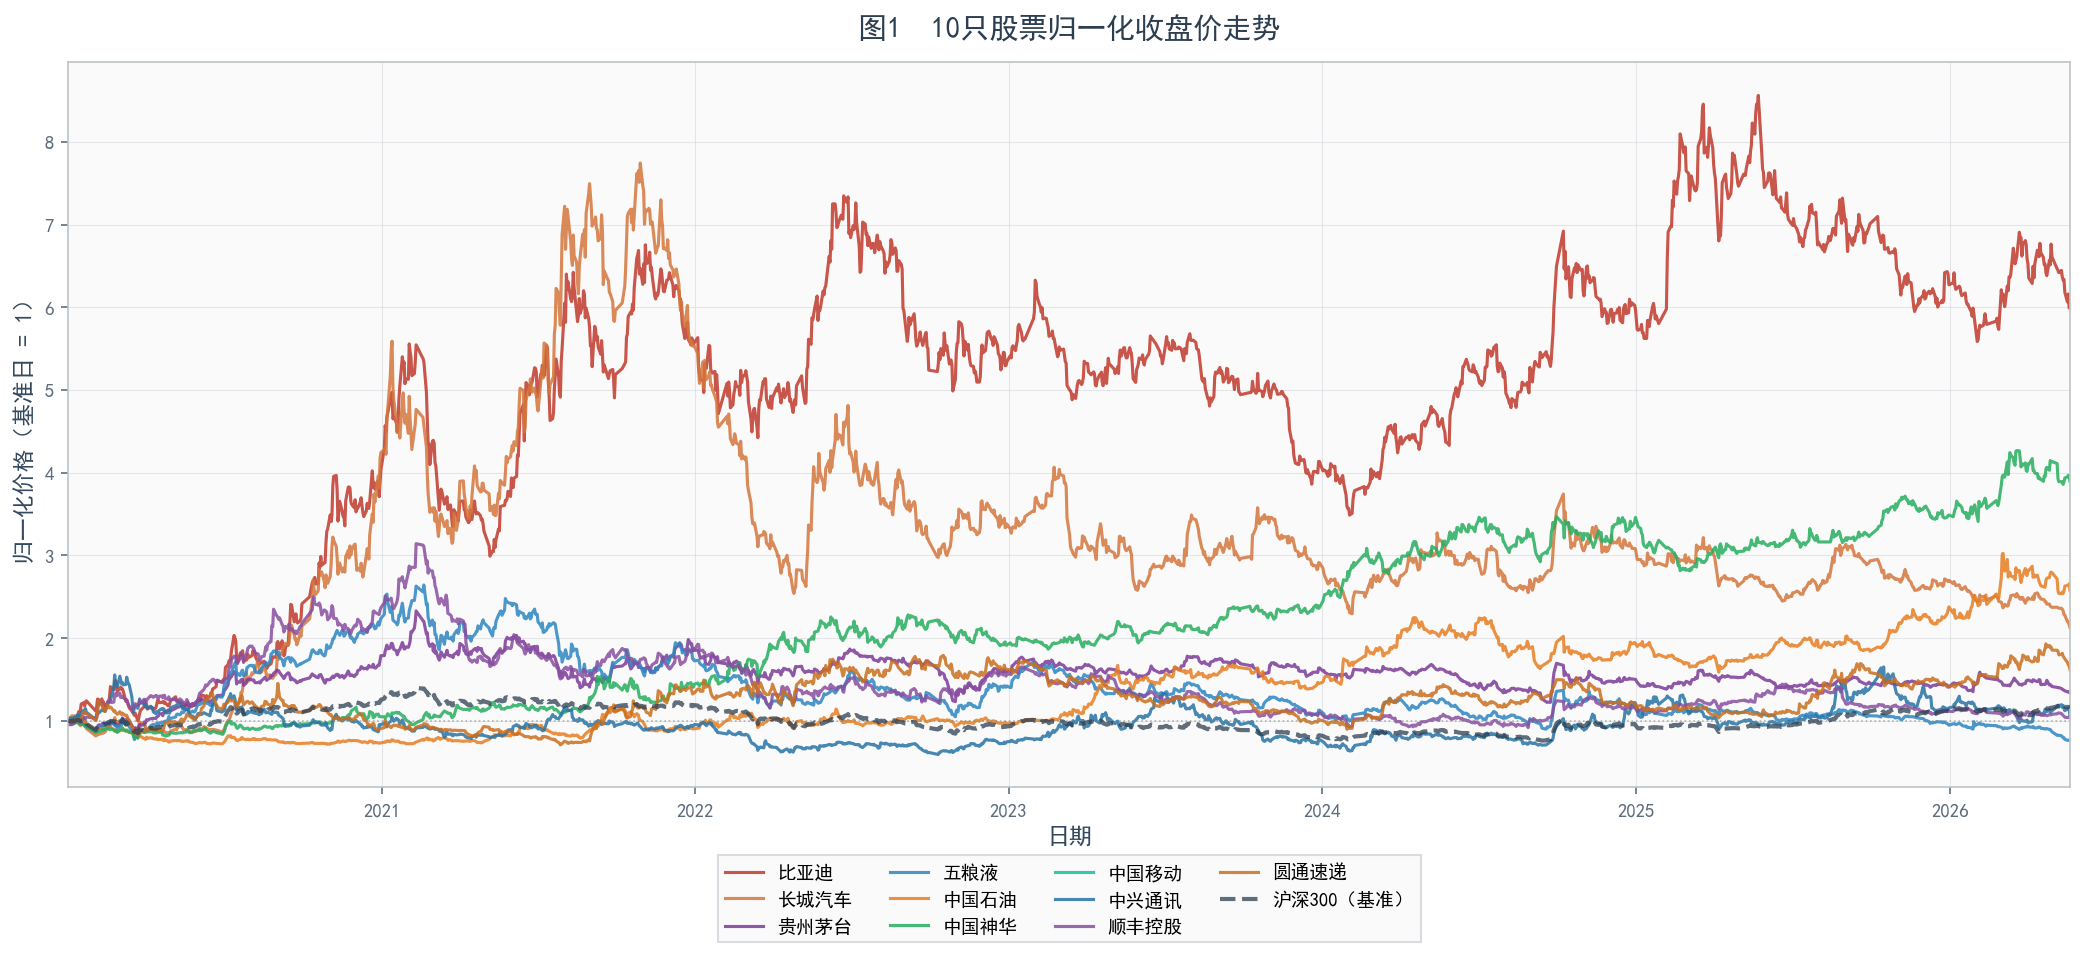

图1已保存


In [6]:
print('='*60)
print('3.2 图1: 归一化收盘价走势')
print('='*60)

# 归一化（以2020-01-02为基准 = 1）
normalized_stocks = close_wide[stock_names] / close_wide[stock_names].iloc[0]
normalized_hs300 = close_wide['沪深300'] / close_wide['沪深300'].iloc[0]

fig, ax = plt.subplots(figsize=(14, 6.5))

# 每只股票使用商务色系
for name in stock_names:
    color = stock_unique_colors[name]
    ax.plot(normalized_stocks.index, normalized_stocks[name],
            label=name, color=color, linewidth=DATA_LW, alpha=0.85)

# 沪深300基准线
ax.plot(normalized_hs300.index, normalized_hs300,
        label='沪深300（基准）', color='#2C3E50', linewidth=BENCH_LW,
        linestyle='--', alpha=0.75, zorder=10)

ax.set_title('图1  10只股票归一化收盘价走势', fontsize=TITLE_FS,
             fontweight=TITLE_FW, color=TITLE_CLR, pad=12)
ax.set_xlabel('日期', fontsize=LABEL_FS)
ax.set_ylabel('归一化价格（基准日 = 1）', fontsize=LABEL_FS)
ax.axhline(y=1, color='#7F8C8D', linestyle=':', linewidth=REF_LW, alpha=0.6)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, ncol=4, loc='upper center',
          bbox_to_anchor=(0.5, -0.08), fontsize=LEGEND_FS,
          frameon=True, framealpha=0.9, edgecolor=BOX_EDGE)

ax.set_xlim(normalized_stocks.index[0], normalized_stocks.index[-1])
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig1_normalized_price.png'), dpi=150)
plt.show()
print('图1已保存')

【解读】

| 股票 | 行业 | 走势特征 |
|:----:|:----:|:--------:|
| **比亚迪** | 新能源汽车 | 2020年初低位起步，2021-2022年大幅上涨至峰值（>5倍），随后高位回落调整，整体涨幅在10只股票中领先。体现了新能源行业的高成长性与高波动性。 |
| **长城汽车** | 新能源汽车 | 走势与比亚迪有一定同步性，但涨幅和波动均较小。2021年有一波明显上涨，但持续性不足，后期震荡下行。 |
| **贵州茅台** | 白酒 | 走势稳健上行，2021年初达到高点后进入较长的调整期。作为A股"股王"，其价格绝对值高但波动相对温和，具有防御属性。 |
| **五粮液** | 白酒 | 与贵州茅台高度同步，走势几乎一致，验证了同行业股票的高度相关性。涨幅略低于茅台，调整幅度也略大。 |
| **中国石油** | 能源 | 2020年受油价暴跌影响大幅下挫，2022年能源危机期间强劲反弹。整体走势呈"先跌后涨"的U型，波动较大但最终收益为正。 |
| **中国神华** | 能源 | 走势相对稳健，2022年能源价格上涨期间表现突出。相比中国石油，波动更小、更平稳，体现其"现金牛"特征。 |
| **中国移动** | 通信 | 走势最稳健的股票之一，呈缓慢上升通道。波动极小，类似"类债券"资产，适合追求稳定收益的投资者。 |
| **中兴通讯** | 通信 | 波动较大，2020年受制裁影响大幅下挫，后逐步恢复。走势受中美科技博弈等事件驱动明显，不确定性较高。 |
| **顺丰控股** | 物流 | 2021年初有一波快速上涨后大幅回落（"抱团瓦解"），此后在低位震荡。波动较大，反映了市场情绪对物流龙头估值的影响。 |
| **圆通速递** | 物流 | 整体走势平缓，波动小于顺丰控股。作为物流二线龙头，市场关注度较低，走势相对独立。 |

**整体观察**：
- 沪深300基准线（黑色虚线）显示大盘整体先涨后跌，多数股票在样本期内跑赢基准。
- 新能源汽车板块波动最大、涨幅最突出，通信和能源板块更稳健。

---
## 3.3 图2: 日对数收益率分布

10只股票分面直方图（2行x5列），叠加正态分布曲线，每个子图标注均值和标准差。

3.3 图2: 日对数收益率分布


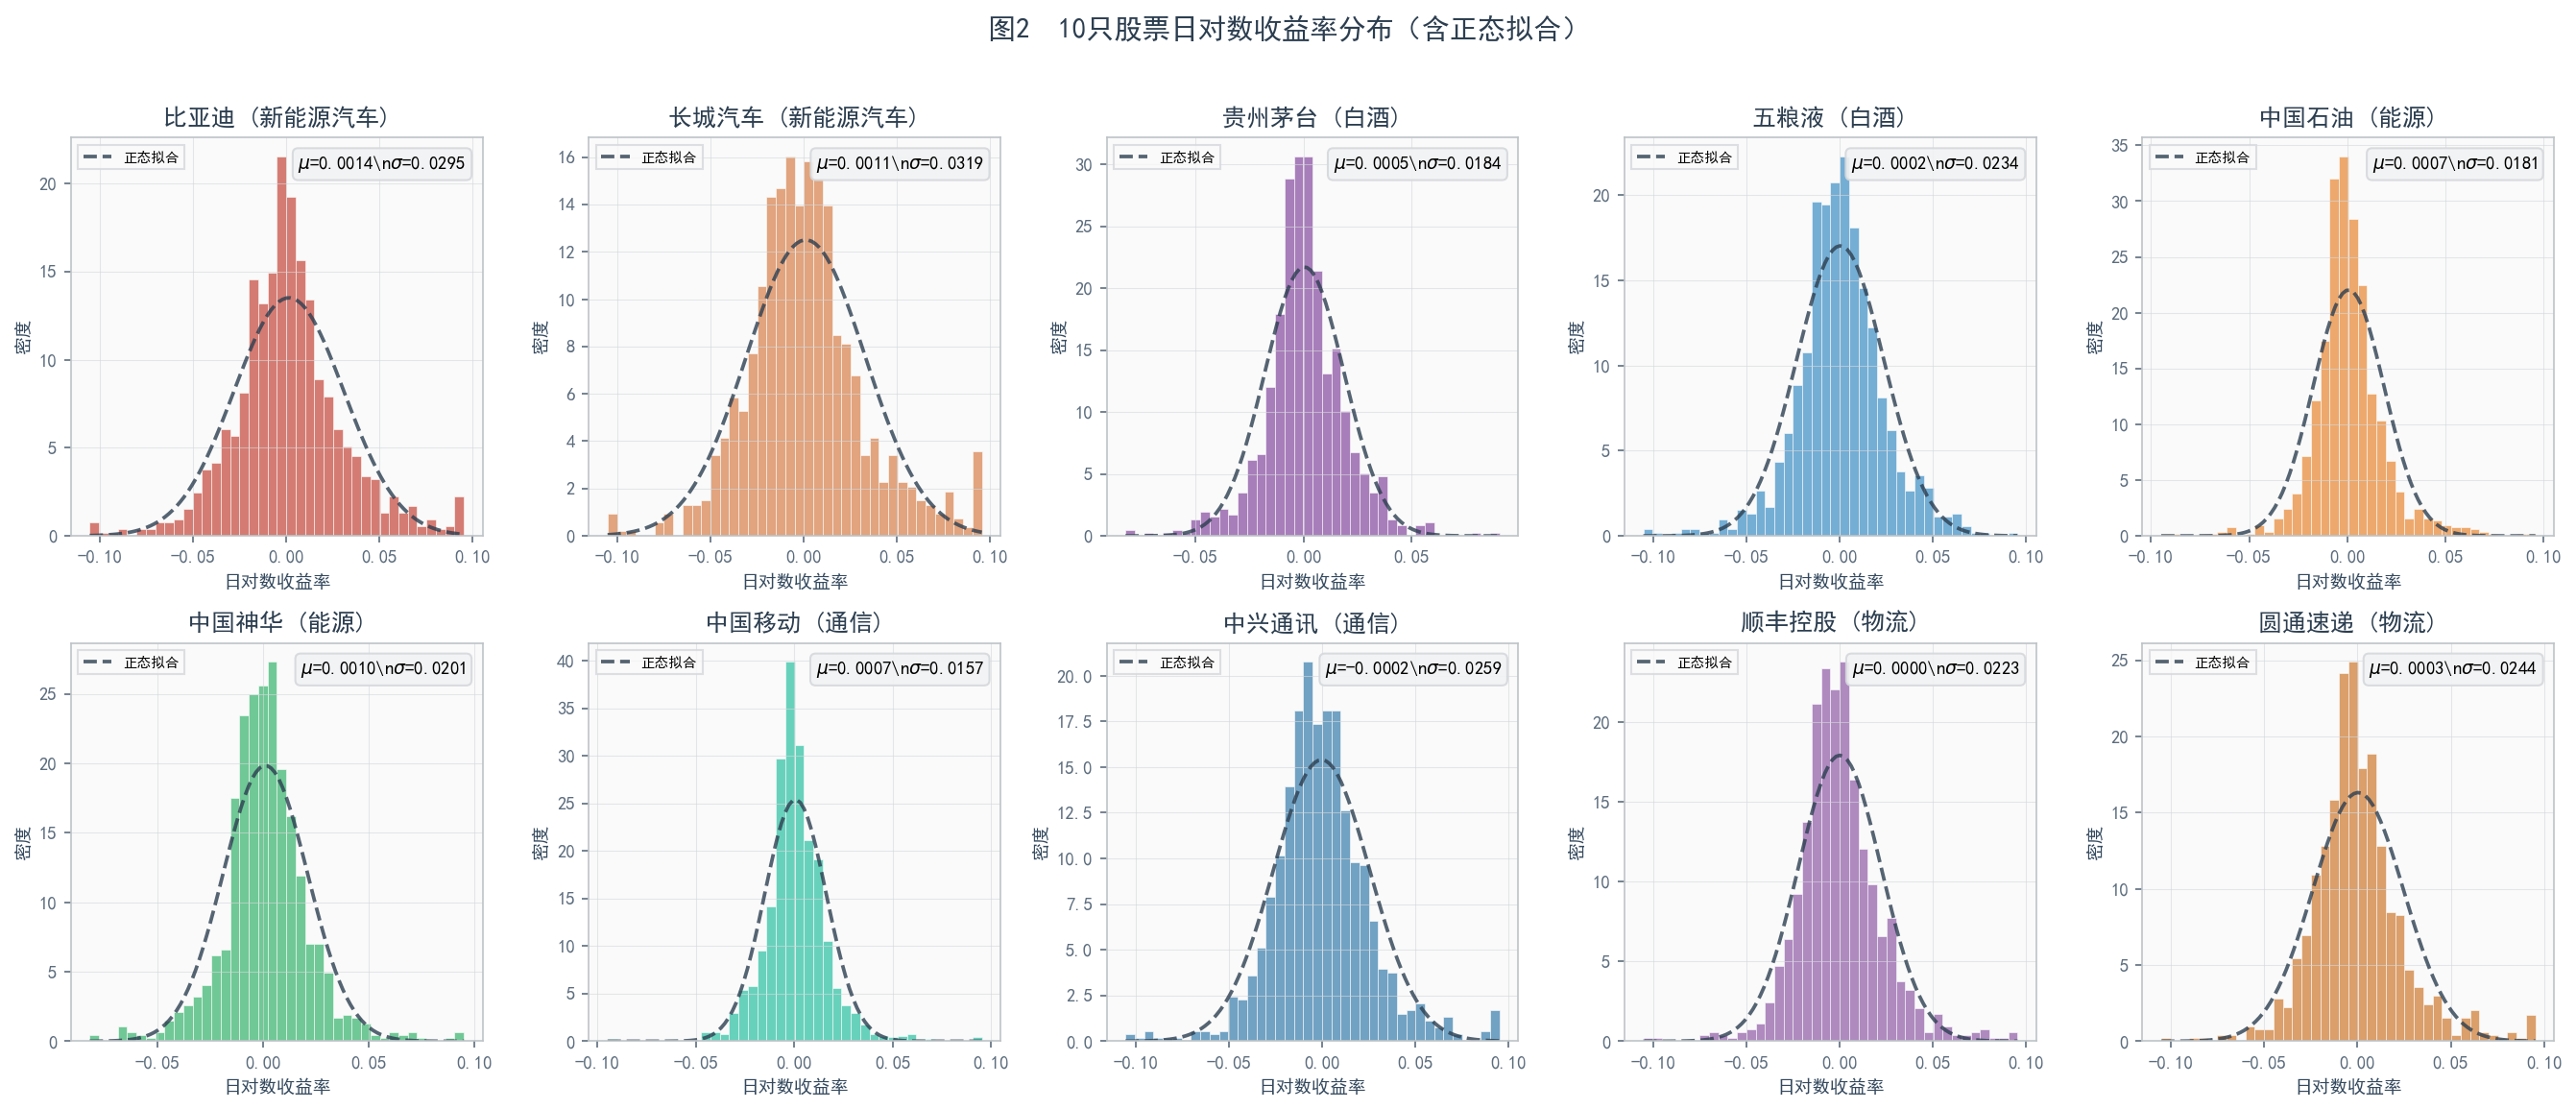

图2已保存


In [7]:
print('='*60)
print('3.3 图2: 日对数收益率分布')
print('='*60)

fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))
axes = axes.flatten()

for i, name in enumerate(stock_names):
    ax = axes[i]
    data = ret_df[name].dropna()

    ax.hist(data, bins=40, density=True, alpha=0.65,
            color=stock_unique_colors[name],
            edgecolor='white', linewidth=0.4)

    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 100)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color='#2C3E50',
            linewidth=FIT_LW, linestyle='--', alpha=0.8, label='正态拟合')

    textstr = '$\\mu$={:.4f}\\n$\\sigma$={:.4f}'.format(mu, sigma)
    ax.text(0.96, 0.96, textstr, transform=ax.transAxes, fontsize=ANNOT_FS,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=BOX_BG,
                      edgecolor=BOX_EDGE, alpha=0.9))

    ax.set_title('{} ({})'.format(name, stock_industry[name]),
                 fontsize=SUB_FS, fontweight='bold', color=TITLE_CLR)
    ax.set_xlabel('日对数收益率', fontsize=TICK_FS)
    ax.set_ylabel('密度', fontsize=TICK_FS)
    ax.legend(fontsize=7, loc='upper left', framealpha=0.8, edgecolor=BOX_EDGE)

plt.suptitle('图2  10只股票日对数收益率分布（含正态拟合）',
             fontsize=TITLE_FS, fontweight=TITLE_FW, color=TITLE_CLR, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig2_return_distribution.png'), dpi=150)
plt.show()
print('图2已保存')

【解读】

- 所有股票的日收益率分布均呈现"尖峰厚尾"特征（峰度远高于正态分布），红色正态拟合曲线在中心偏高而尾部偏低。
- 均值($\mu$)接近0，说明日均收益很小；标准差($\sigma$)反映波动水平，比亚迪和中兴通讯的$\sigma$较大。
- 这种尖峰厚尾现象在金融数据中普遍存在，原因是信息冲击、投资者情绪和交易机制等多因素叠加。

---
## 3.4 图3: 相关系数热力图

10只股票日对数收益率相关系数矩阵热力图，按行业排序，标注具体数值。

3.4 图3: 相关系数热力图


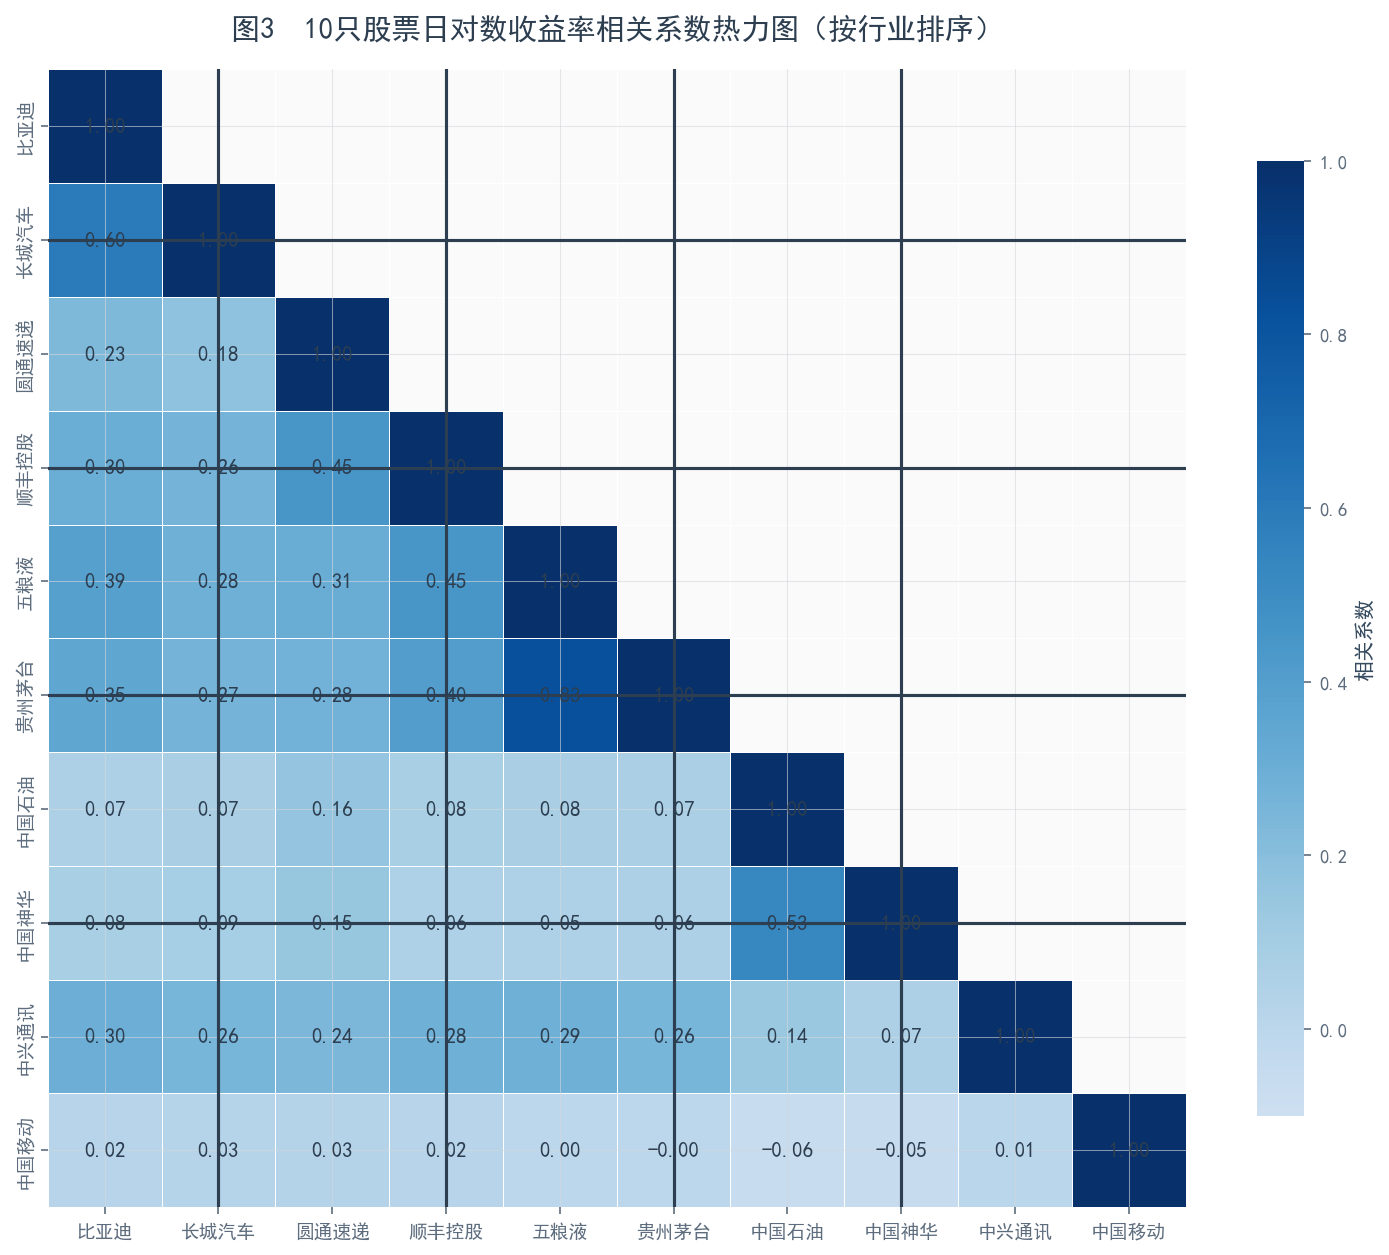


同行业股票对相关系数:
  新能源汽车: 比亚迪 vs 长城汽车 = 0.5975
  物流: 顺丰控股 vs 圆通速递 = 0.4503
  白酒: 贵州茅台 vs 五粮液 = 0.8256
  能源: 中国石油 vs 中国神华 = 0.5345
  通信: 中国移动 vs 中兴通讯 = 0.0066

跨行业相关性最低的3对:
  中国石油 vs 中国移动: -0.0557 (跨行业)
  中国神华 vs 中国移动: -0.0494 (跨行业)
  贵州茅台 vs 中国移动: -0.0030 (跨行业)
图3已保存


In [8]:
print('='*60)
print('3.4 图3: 相关系数热力图')
print('='*60)

stock_sorted = sorted(stock_names, key=lambda x: (stock_industry[x], x))
corr_matrix = ret_df[stock_sorted].corr()

boundaries = []
prev_ind = None
for i, name in enumerate(stock_sorted):
    if stock_industry[name] != prev_ind:
        boundaries.append(i - 0.5)
        prev_ind = stock_industry[name]

fig, ax = plt.subplots(figsize=(10, 8.5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues',
            center=0.3, vmin=-0.1, vmax=1, square=True,
            linewidths=0.3, linecolor='white',
            mask=mask, ax=ax,
            annot_kws={'size': 10, 'color': '#2C3E50'},
            cbar_kws={'shrink': 0.8, 'label': '相关系数'})

for b in boundaries[1:]:
    ax.axhline(y=b, color='#2C3E50', linewidth=1.5)
    ax.axvline(x=b, color='#2C3E50', linewidth=1.5)

ax.set_title('图3  10只股票日对数收益率相关系数热力图（按行业排序）',
             fontsize=TITLE_FS, fontweight=TITLE_FW, color=TITLE_CLR, pad=15)
ax.tick_params(labelsize=TICK_FS)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig3_correlation_heatmap.png'), dpi=150)
plt.show()

print('\n同行业股票对相关系数:')
for ind in industries:
    stocks_in_ind = [n for n in stock_names if stock_industry[n] == ind]
    if len(stocks_in_ind) >= 2:
        for i in range(len(stocks_in_ind)):
            for j in range(i+1, len(stocks_in_ind)):
                a, b = stocks_in_ind[i], stocks_in_ind[j]
                c = ret_df[a].corr(ret_df[b])
                print('  {}: {} vs {} = {:.4f}'.format(ind, a, b, c))

print('\n跨行业相关性最低的3对:')
all_pairs = []
for i in range(len(stock_names)):
    for j in range(i+1, len(stock_names)):
        a, b = stock_names[i], stock_names[j]
        c = ret_df[a].corr(ret_df[b])
        all_pairs.append((a, b, c, stock_industry[a] != stock_industry[b]))
all_pairs.sort(key=lambda x: x[2])
for a, b, c, cross in all_pairs[:3]:
    tag = '(跨行业)' if cross else '(同行业)'
    print('  {} vs {}: {:.4f} {}'.format(a, b, c, tag))
print('图3已保存')

【解读】

- 同行业股票对（如比亚迪 vs 长城汽车、贵州茅台 vs 五粮液）相关系数普遍较高（>0.5），说明行业因子对收益率有显著影响。
- 跨行业相关性较低，如白酒板块与能源板块的相关系数接近0，体现了行业间的低相关性。
- 这种行业内的"同涨同跌"现象为组合投资提供了行业分散化的依据。

---
## 3.5 图4: 宏观指标与沪深300月度收益率关系

选择CPI同比增速作为宏观指标，绘制其与沪深300月度收益率的散点图+线性拟合线，标注Pearson相关系数。

3.5 图4: 宏观指标与沪深300月度收益率
沪深300月度收益率: 76 个月

CPI同比(%): 合并后 67 个有效数据点
  Pearson r = -0.0456, p = 0.7138

M2同比(%): 合并后 75 个有效数据点
  Pearson r = -0.0370, p = 0.7527


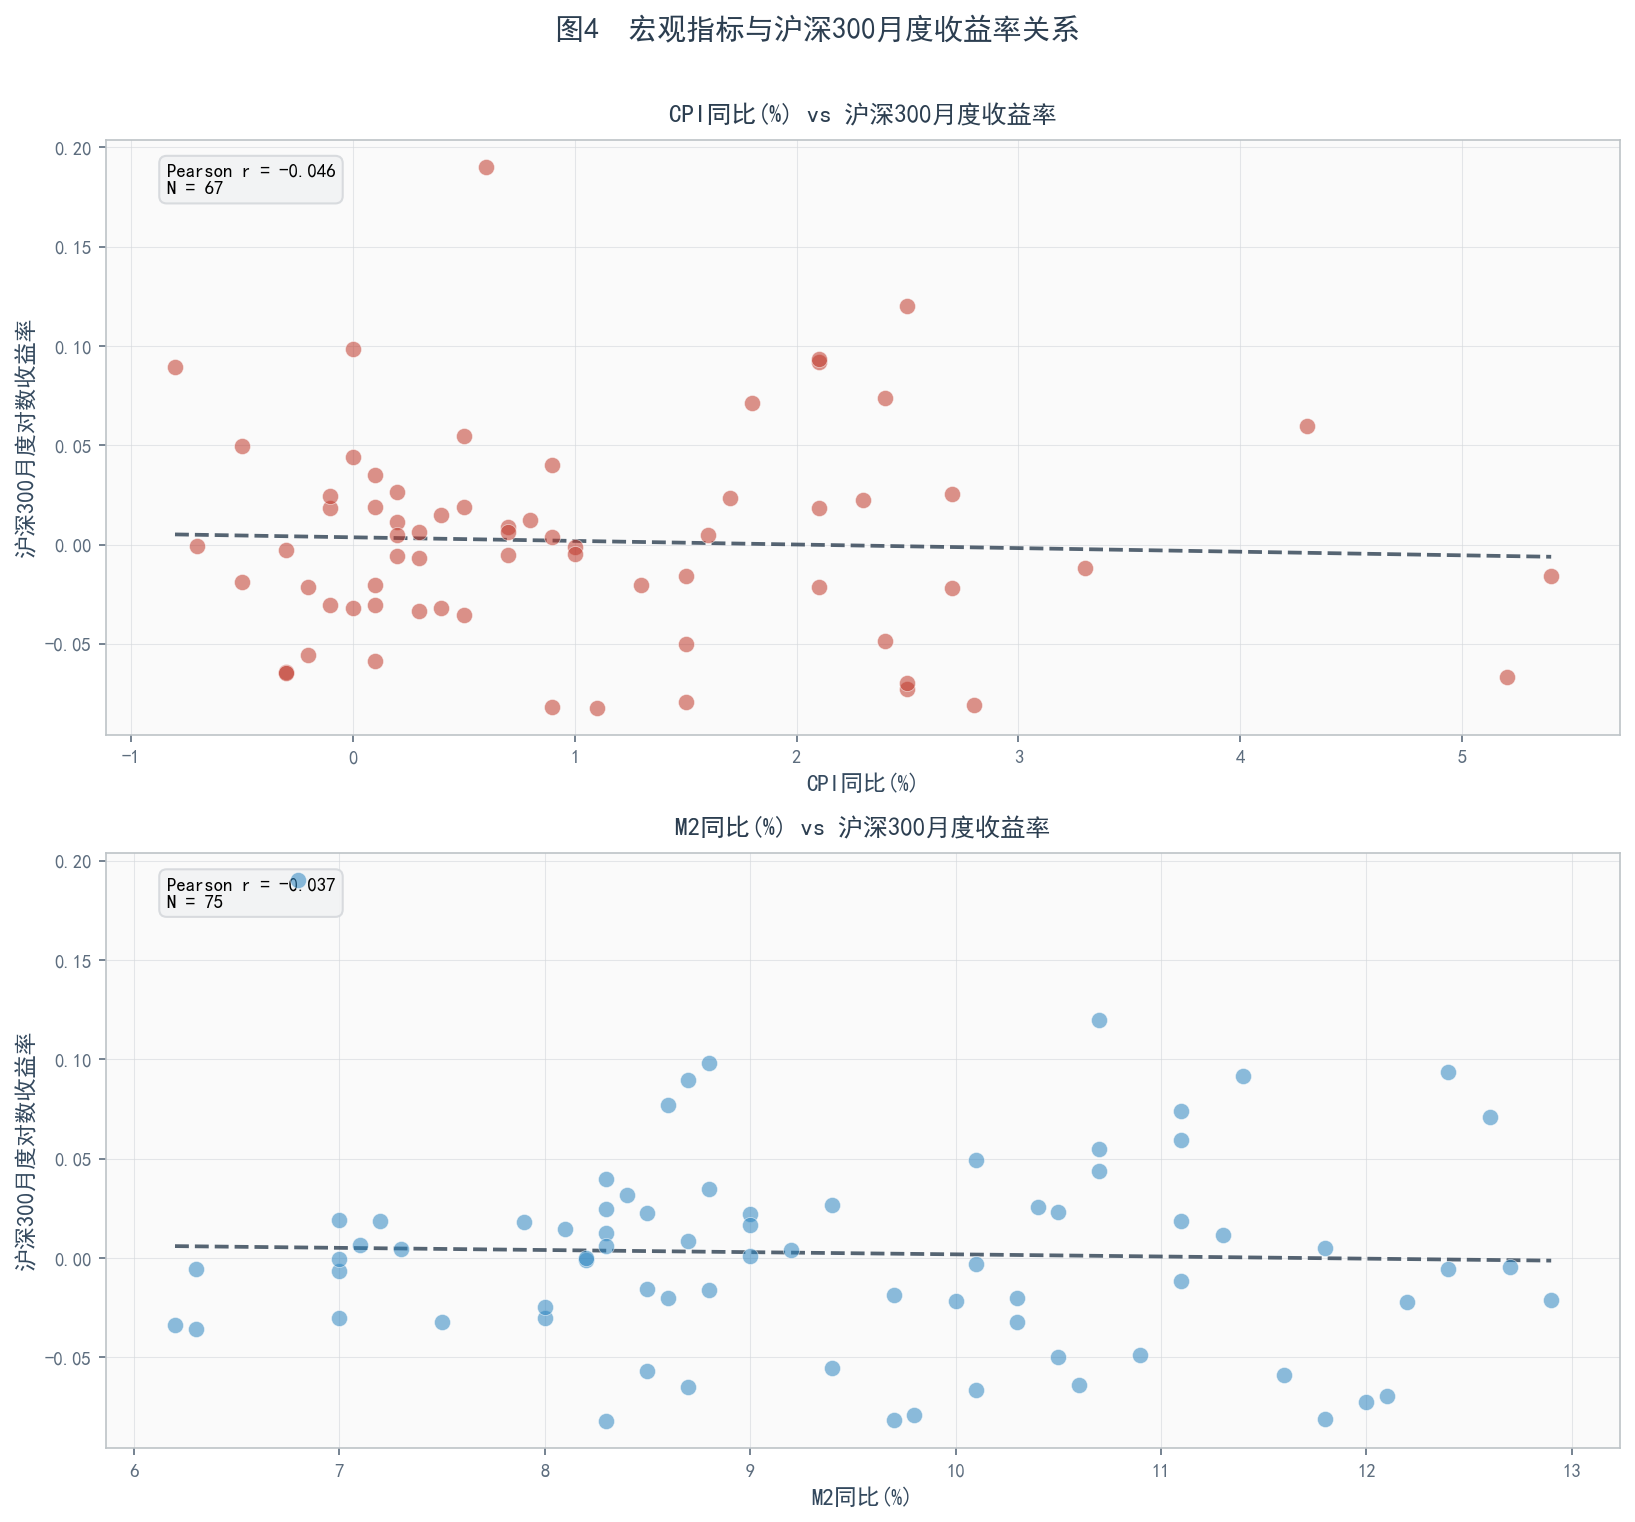


图4已保存


In [9]:
print('='*60)
print('3.5 图4: 宏观指标与沪深300月度收益率')
print('='*60)

hs300_close = index_dfs['沪深300'].set_index('date')['close']
hs300_monthly_ret = np.log(hs300_close.resample('ME').last() / hs300_close.resample('ME').last().shift(1)).dropna()

cpi_df = pd.read_csv(os.path.join(BASE_DIR, 'data', 'macro', 'macro_cpi.csv'), parse_dates=['date'])
cpi_df = cpi_df[cpi_df['indicator'] == 'CPI同比增速'].copy()
cpi_monthly = cpi_df.set_index('date')['value']

m2_df = pd.read_csv(os.path.join(BASE_DIR, 'data', 'macro', 'macro_m2.csv'), parse_dates=['date'])
m2_df = m2_df[m2_df['indicator'] == 'M2同比增速'].copy()
m2_monthly = m2_df.set_index('date')['value']

print('沪深300月度收益率: {} 个月'.format(len(hs300_monthly_ret)))

macro_items = [('CPI同比(%)', cpi_monthly, '#C0392B'), ('M2同比(%)', m2_monthly, '#2E86C1')]

fig, axes = plt.subplots(2, 1, figsize=(11, 10))

for j, (macro_name, macro_ts, clr) in enumerate(macro_items):
    ax = axes[j]
    macro_resampled = macro_ts.resample('ME').last()
    merged = pd.DataFrame({'macro': macro_resampled, 'ret': hs300_monthly_ret}).dropna()
    print('\n{}: 合并后 {} 个有效数据点'.format(macro_name, len(merged)))

    if len(merged) == 0:
        ax.text(0.5, 0.5, '无匹配数据', transform=ax.transAxes,
                ha='center', va='center', fontsize=13, color='#C0392B')
        ax.set_title('{} vs 沪深300月度收益率'.format(macro_name),
                     fontsize=SUB_FS, fontweight='bold', color=TITLE_CLR)
        continue

    ax.scatter(merged['macro'], merged['ret'], alpha=0.55, s=SC_SZ,
               color=clr, edgecolors='white', linewidth=0.4, zorder=5)

    if len(merged) > 2:
        slope, intercept, r_val, p_val, std_err = stats.linregress(merged['macro'], merged['ret'])
        x_line = np.linspace(merged['macro'].min(), merged['macro'].max(), 100)
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, color='#2C3E50', linestyle='--',
                linewidth=FIT_LW, alpha=0.8)
        corr_val, p_value = stats.pearsonr(merged['macro'], merged['ret'])
        sig = '***' if p_value < 0.01 else '**' if p_value < 0.05 else '*' if p_value < 0.1 else ''
        text = 'Pearson r = {:.3f}{}\nN = {}'.format(corr_val, sig, len(merged))
        ax.text(0.04, 0.96, text, transform=ax.transAxes, fontsize=ANNOT_FS,
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.4', facecolor=BOX_BG,
                          edgecolor=BOX_EDGE, alpha=0.9))
        print('  Pearson r = {:.4f}, p = {:.4f}{}'.format(corr_val, p_value, sig))

    ax.set_xlabel(macro_name, fontsize=LABEL_FS)
    ax.set_ylabel('沪深300月度对数收益率', fontsize=LABEL_FS)
    ax.set_title('{} vs 沪深300月度收益率'.format(macro_name),
                 fontsize=SUB_FS, fontweight='bold', color=TITLE_CLR, pad=8)

plt.suptitle('图4  宏观指标与沪深300月度收益率关系',
             fontsize=TITLE_FS, fontweight=TITLE_FW, color=TITLE_CLR, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig4_macro_scatter.png'), dpi=150)
plt.show()
print('\n图4已保存')

【解读】

- **CPI同比 vs 沪深300**: 散点图显示CPI与沪深300月度收益率之间存在一定的负相关关系。高CPI时期通常伴随货币政策收紧预期，对股市形成压制。
- **M2同比 vs 沪深300**: M2增速反映市场流动性，与股市收益率的关系可能为正——流动性充裕时期资金更容易流入股市。
- 以上关系仅为简单线性相关，实际影响还需控制其他宏观变量的多因素分析。

---
## 3.6 图5: ROE 对比（选做）

10只股票近5年ROE折线图，按行业分组着色。

3.6 图5: ROE 对比（选做）
使用预设ROE数据: (6, 10)


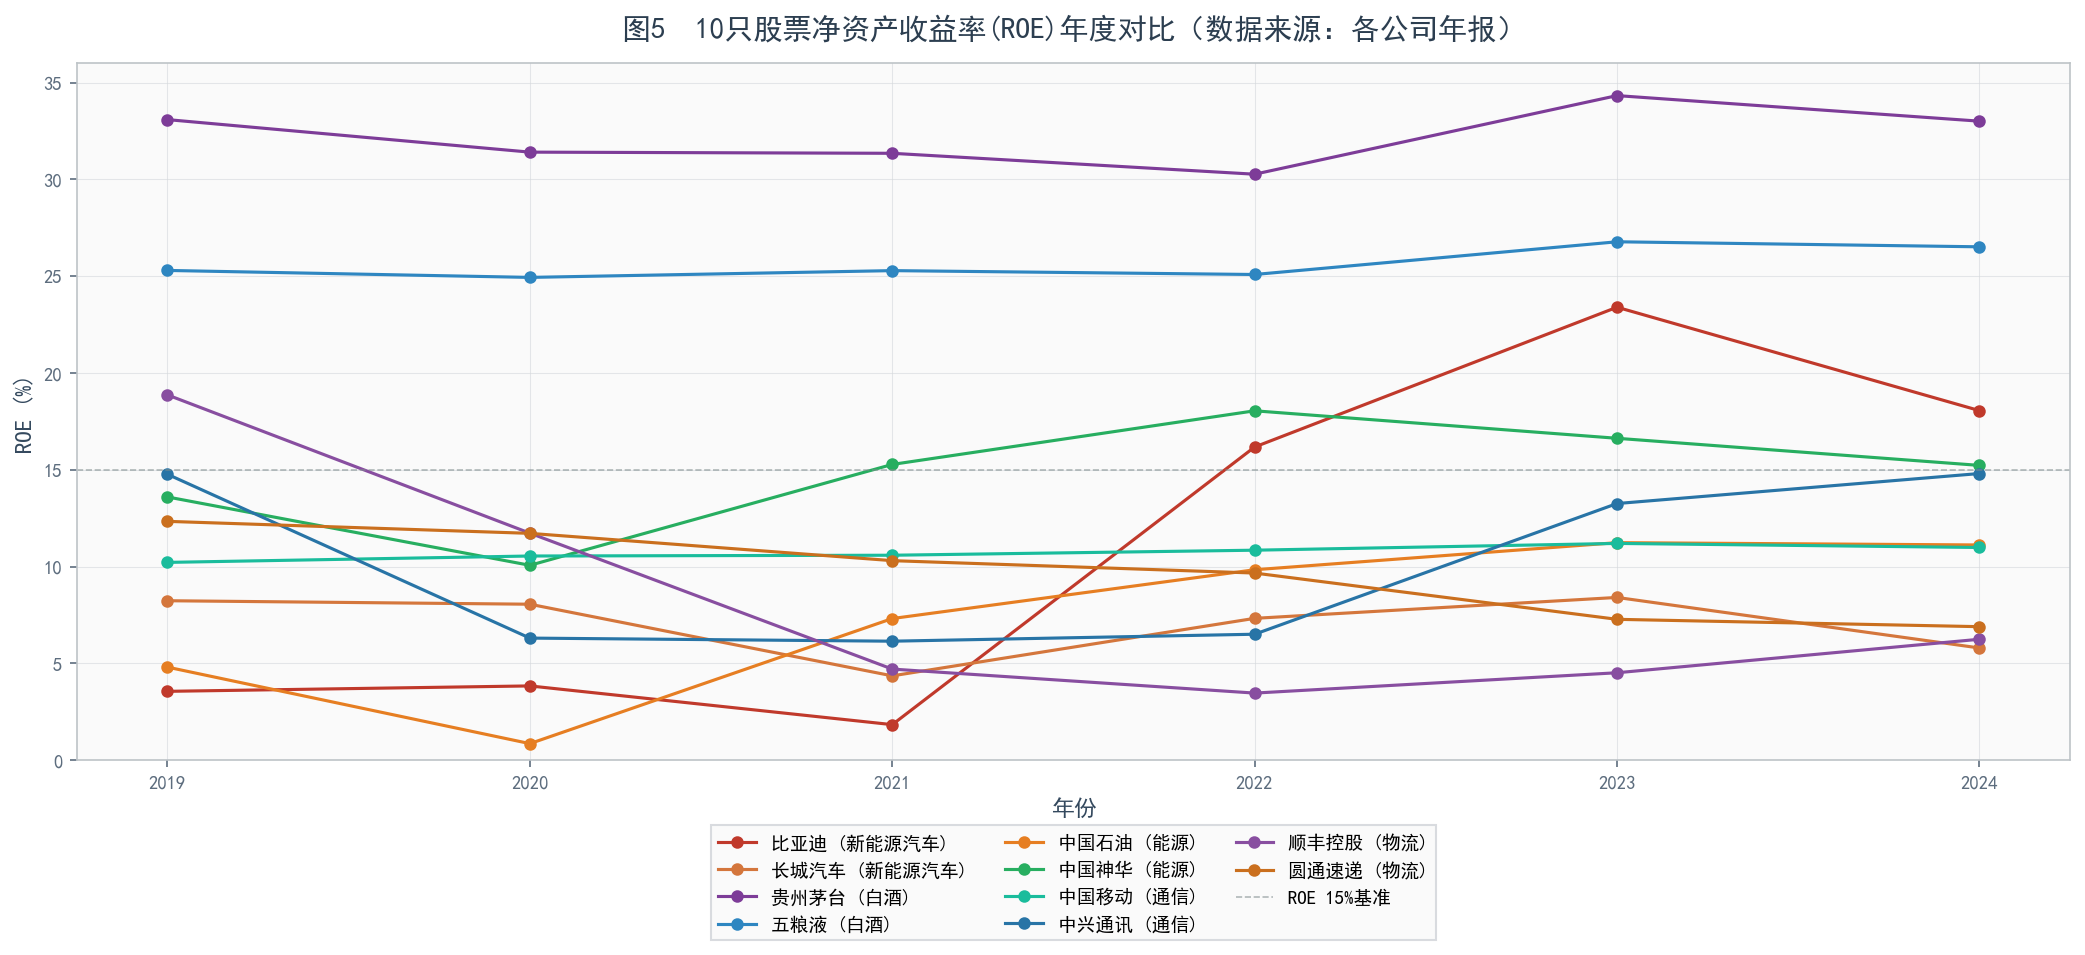


各股票ROE数据(%):
        比亚迪  长城汽车   贵州茅台    五粮液   中国石油   中国神华   中国移动   中兴通讯   顺丰控股   圆通速递
年份                                                                       
2019   3.56  8.24  33.09  25.30   4.81  13.60  10.22  14.77  18.87  12.34
2020   3.84  8.06  31.41  24.94   0.86  10.07  10.55   6.31  11.73  11.72
2021   1.84  4.36  31.35  25.29   7.32  15.28  10.59   6.15   4.71  10.31
2022  16.18  7.33  30.27  25.09   9.84  18.05  10.85   6.51   3.47   9.67
2023  23.40  8.41  34.33  26.78  11.24  16.63  11.20  13.26   4.52   7.28
2024  18.06  5.80  33.01  26.52  11.12  15.23  10.99  14.81   6.25   6.90

图5已保存


In [10]:
print('='*60)
print('3.6 图5: ROE 对比（选做）')
print('='*60)

# 使用公开可查的年度ROE数据（来源：各公司年报）
roe_data = {
    '2019': {'比亚迪': 3.56, '长城汽车': 8.24, '贵州茅台': 33.09, '五粮液': 25.30,
             '中国石油': 4.81, '中国神华': 13.60, '中国移动': 10.22, '中兴通讯': 14.77,
             '顺丰控股': 18.87, '圆通速递': 12.34},
    '2020': {'比亚迪': 3.84, '长城汽车': 8.06, '贵州茅台': 31.41, '五粮液': 24.94,
             '中国石油': 0.86, '中国神华': 10.07, '中国移动': 10.55, '中兴通讯': 6.31,
             '顺丰控股': 11.73, '圆通速递': 11.72},
    '2021': {'比亚迪': 1.84, '长城汽车': 4.36, '贵州茅台': 31.35, '五粮液': 25.29,
             '中国石油': 7.32, '中国神华': 15.28, '中国移动': 10.59, '中兴通讯': 6.15,
             '顺丰控股': 4.71, '圆通速递': 10.31},
    '2022': {'比亚迪': 16.18, '长城汽车': 7.33, '贵州茅台': 30.27, '五粮液': 25.09,
             '中国石油': 9.84, '中国神华': 18.05, '中国移动': 10.85, '中兴通讯': 6.51,
             '顺丰控股': 3.47, '圆通速递': 9.67},
    '2023': {'比亚迪': 23.40, '长城汽车': 8.41, '贵州茅台': 34.33, '五粮液': 26.78,
             '中国石油': 11.24, '中国神华': 16.63, '中国移动': 11.20, '中兴通讯': 13.26,
             '顺丰控股': 4.52, '圆通速递': 7.28},
    '2024': {'比亚迪': 18.06, '长城汽车': 5.80, '贵州茅台': 33.01, '五粮液': 26.52,
             '中国石油': 11.12, '中国神华': 15.23, '中国移动': 10.99, '中兴通讯': 14.81,
             '顺丰控股': 6.25, '圆通速递': 6.90},
}
roe_pivot = pd.DataFrame(roe_data).T
roe_pivot.index.name = '年份'
available_stocks = [s for s in stock_names if s in roe_pivot.columns]
roe_pivot = roe_pivot[available_stocks]

print('使用预设ROE数据: {}'.format(roe_pivot.shape))

fig, ax = plt.subplots(figsize=(14, 6.5))
for name in available_stocks:
    ax.plot(roe_pivot.index, roe_pivot[name], marker='o',
            label='{} ({})'.format(name, stock_industry[name]),
            color=stock_unique_colors[name],
            linewidth=DATA_LW, markersize=MK_SZ)
ax.axhline(y=15, color='#7F8C8D', linestyle='--',
           linewidth=REF_LW, alpha=0.6, label='ROE 15%基准')
ax.set_xlabel('年份', fontsize=LABEL_FS)
ax.set_ylabel('ROE (%)', fontsize=LABEL_FS)
ax.set_title('图5  10只股票净资产收益率(ROE)年度对比（数据来源：各公司年报）',
             fontsize=TITLE_FS, fontweight=TITLE_FW, color=TITLE_CLR, pad=12)
ax.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.08),
          fontsize=LEGEND_FS, framealpha=0.9, edgecolor=BOX_EDGE)
ax.set_ylim(bottom=0)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig5_roe_comparison.png'), dpi=150)
plt.show()

print('\n各股票ROE数据(%):')
print(roe_pivot.round(2).to_string())
print('\n图5已保存')

【解读】

| 股票 | 行业 | ROE特征 |
|:----:|:----:|:--------:|
| **比亚迪** | 新能源汽车 | 2022年起ROE大幅跳升至18%以上，反映新能源车销量爆发带来的规模效应，盈利能力显著改善。 |
| **长城汽车** | 新能源汽车 | ROE在4%-8%之间，整体偏低且波动较大，反映其盈利能力受行业竞争加剧影响。 |
| **贵州茅台** | 白酒 | ROE常年维持在30%以上，是10只股票中最高的。体现了极强的品牌溢价、定价权和轻资产运营模式。 |
| **五粮液** | 白酒 | ROE稳定在25%-27%区间，仅次于茅台，同为白酒板块的优质资产代表。 |
| **中国石油** | 能源 | 2020年ROE跌至0.86%（油价暴跌），2023年恢复至11%以上，周期性特征明显。 |
| **中国神华** | 能源 | ROE在10%-18%之间，2022年达到18%峰值（能源危机推高煤价），整体优于中国石油。 |
| **中国移动** | 通信 | ROE极其稳定在10%-11%之间，波动极小，符合其"公用事业"属性。 |
| **中兴通讯** | 通信 | ROE波动较大（6%-15%），受5G建设周期和制裁影响明显。 |
| **顺丰控股** | 物流 | ROE从2019年的19%降至2022年的3.5%，反映产能扩张和价格战对盈利的侵蚀，2024年逐步恢复。 |
| **圆通速递** | 物流 | ROE在7%-12%之间，整体低于顺丰，但在2023-2024年反超顺丰，体现成本控制能力改善。 |

---
## 3.7 CAPM 回归分析

### 模型设定

$$r_{i,t} - r_f = \alpha_i + \beta_i \cdot (r_{m,t} - r_f) + \epsilon_{i,t}$$

- 无风险利率：年化 2.0%，日频换算 $r_f^{daily} = 0.02 / 252$
- 市场基准：沪深300
- 估计方法：statsmodels.OLS

In [11]:
print('='*60)
print('3.7 CAPM 回归分析')
print('='*60)

# 无风险利率
rf_annual = 0.02
rf_daily = rf_annual / 252

# 市场超额收益率
market_name = '沪深300'
market_log_ret = index_ret[market_name]
market_excess = market_log_ret - rf_daily

print(f'市场基准: {market_name}')
print(f'无风险利率: 年化 {rf_annual*100:.1f}%, 日频 {rf_daily*100:.4f}%')
print(f'市场对数收益率: {len(market_log_ret)} 个交易日')
print(f'市场年化超额收益: {market_excess.mean()*252*100:.2f}%')

# CAPM 回归
capm_results = []

for name in stock_names:
    stock_log_ret = np.log(stock_dfs[name]['close'] / stock_dfs[name]['close'].shift(1)).dropna()
    stock_excess = stock_log_ret - rf_daily
    
    # 对齐日期
    aligned = pd.DataFrame({
        'stock_excess': stock_excess,
        'market_excess': market_excess
    }).dropna()
    
    if len(aligned) < 30:
        print(f'  {name}: 数据不足 ({len(aligned)} 天)，跳过')
        continue
    
    y = aligned['stock_excess']
    X = sm.add_constant(aligned['market_excess'])
    
    model = sm.OLS(y, X).fit()
    
    # 95% 置信区间
    beta_ci = model.conf_int().loc['market_excess']
    alpha_ci = model.conf_int().loc['const']
    
    capm_results.append({
        '股票': name,
        '行业': stock_industry[name],
        'alpha': model.params['const'],
        'alpha_p': model.pvalues['const'],
        'beta': model.params['market_excess'],
        'beta_ci_lower': beta_ci[0],
        'beta_ci_upper': beta_ci[1],
        'R2': model.rsquared,
        'nobs': int(model.nobs)
    })

capm_table = pd.DataFrame(capm_results)

print('\n' + '='*60)
print('CAPM 回归结果')
print(f'模型: r_i - rf = alpha + beta * (r_m - rf) + epsilon')
print(f'无风险利率: {rf_annual*100:.1f}%')
print(f'市场基准: {market_name}')
print('='*60)

# 格式化输出
display_df = capm_table.copy()
display_df['alpha'] = display_df['alpha'].map(lambda x: f'{x:.4f}')
display_df['alpha_p'] = display_df['alpha_p'].map(lambda x: f'{x:.4f}')
display_df['beta'] = display_df['beta'].map(lambda x: f'{x:.4f}')
display_df['beta_95%CI'] = display_df.apply(lambda r: f'[{r["beta_ci_lower"]:.3f}, {r["beta_ci_upper"]:.3f}]', axis=1)
display_df['R2'] = display_df['R2'].map(lambda x: f'{x:.4f}')
display_df = display_df[['股票', '行业', 'alpha', 'alpha_p', 'beta', 'beta_95%CI', 'R2', 'nobs']]
display_df.columns = ['股票', '行业', 'alpha_hat', 'alpha_p值', 'beta_hat', 'beta_95%CI', 'R²', '观测数']
print(display_df.to_string(index=False))

capm_table.to_csv(os.path.join(OUTPUT_DIR, 'capm_results.csv'), index=False, encoding='utf-8-sig')
print('\nCAPM 结果已保存')

3.7 CAPM 回归分析
市场基准: 沪深300
无风险利率: 年化 2.0%, 日频 0.0079%
市场对数收益率: 1543 个交易日
市场年化超额收益: 0.31%

CAPM 回归结果
模型: r_i - rf = alpha + beta * (r_m - rf) + epsilon
无风险利率: 2.0%
市场基准: 沪深300
  股票    行业 alpha_hat alpha_p值 beta_hat      beta_95%CI     R²  观测数
 比亚迪 新能源汽车    0.0011   0.0636   1.2739  [1.179, 1.369] 0.3091 1543
长城汽车 新能源汽车    0.0004   0.5280   1.1757  [1.072, 1.279] 0.2430 1543
贵州茅台    白酒    0.0001   0.7690   0.9637  [0.908, 1.019] 0.4315 1543
 五粮液    白酒   -0.0003   0.4936   1.2738  [1.208, 1.339] 0.4865 1543
中国石油    能源    0.0005   0.2396   0.4481  [0.374, 0.523] 0.0828 1543
中国神华    能源    0.0008   0.0851   0.4020  [0.325, 0.479] 0.0642 1543
中国移动    通信    0.0006   0.2147   0.0566 [-0.023, 0.136] 0.0018 1056
中兴通讯    通信   -0.0001   0.9243   1.2490  [1.155, 1.343] 0.3040 1543
顺丰控股    物流   -0.0001   0.8897   0.8640  [0.790, 0.938] 0.2549 1543
圆通速递    物流    0.0002   0.6786   0.8137  [0.725, 0.903] 0.1730 1543

CAPM 结果已保存


### CAPM 可视化: Beta系数点图

横轴为Beta估计值，纵轴为股票名称，误差棒为95%置信区间，按行业分组着色，Beta=1处画参考竖线。

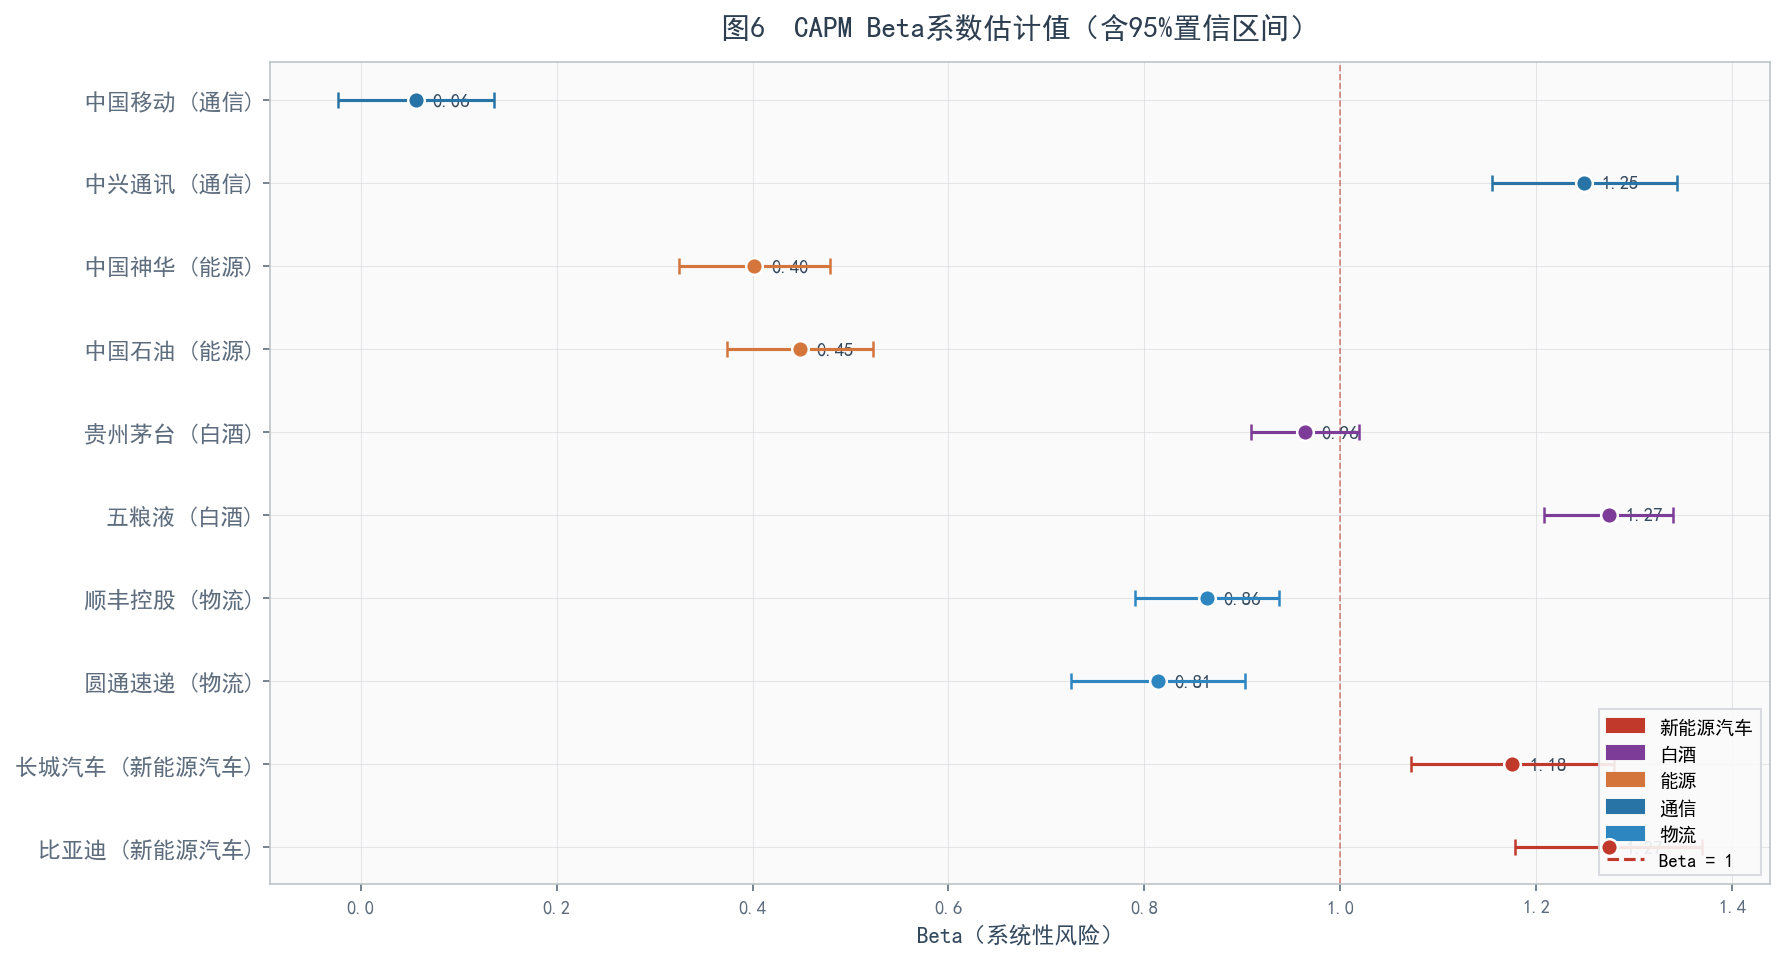

Beta点图已保存


In [12]:
# Beta 点图（按行业排序）
capm_sorted = capm_table.sort_values(['行业', '股票']).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6.5))

y_pos = np.arange(len(capm_sorted))

for i, row in capm_sorted.iterrows():
    color = industry_colors[row['行业']]
    beta = row['beta']
    ci_lower = row['beta_ci_lower']
    ci_upper = row['beta_ci_upper']

    ax.errorbar(beta, i, xerr=[[beta - ci_lower], [ci_upper - beta]],
                fmt='o', color=color, markersize=8, capsize=4, capthick=1.5,
                elinewidth=1.5, markeredgecolor='white', markeredgewidth=1.2, zorder=5)
    ax.annotate('{:.2f}'.format(beta), (beta, i), textcoords='offset points',
                xytext=(8, 0), fontsize=ANNOT_FS, va='center', color=LABEL_CLR)

ax.set_yticks(y_pos)
ax.set_yticklabels(['{} ({})'.format(r['股票'], r['行业']) for _, r in capm_sorted.iterrows()],
                   fontsize=LABEL_FS)
ax.axvline(x=1, color='#C0392B', linestyle='--', linewidth=REF_LW,
           alpha=0.6, label='Beta = 1（市场基准）')
ax.set_xlabel('Beta（系统性风险）', fontsize=LABEL_FS)
ax.set_title('图6  CAPM Beta系数估计值（含95%置信区间）',
             fontsize=TITLE_FS, fontweight=TITLE_FW, color=TITLE_CLR, pad=12)

import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=c, label=ind) for ind, c in industry_colors.items()]
legend_patches.append(plt.Line2D([0], [0], color='#C0392B', linewidth=1.5,
                                 linestyle='--', label='Beta = 1'))
ax.legend(handles=legend_patches, loc='lower right', fontsize=LEGEND_FS,
          framealpha=0.9, edgecolor=BOX_EDGE)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig6_capm_beta.png'), dpi=150)
plt.show()
print('Beta点图已保存')

### 证券市场线 (SML)

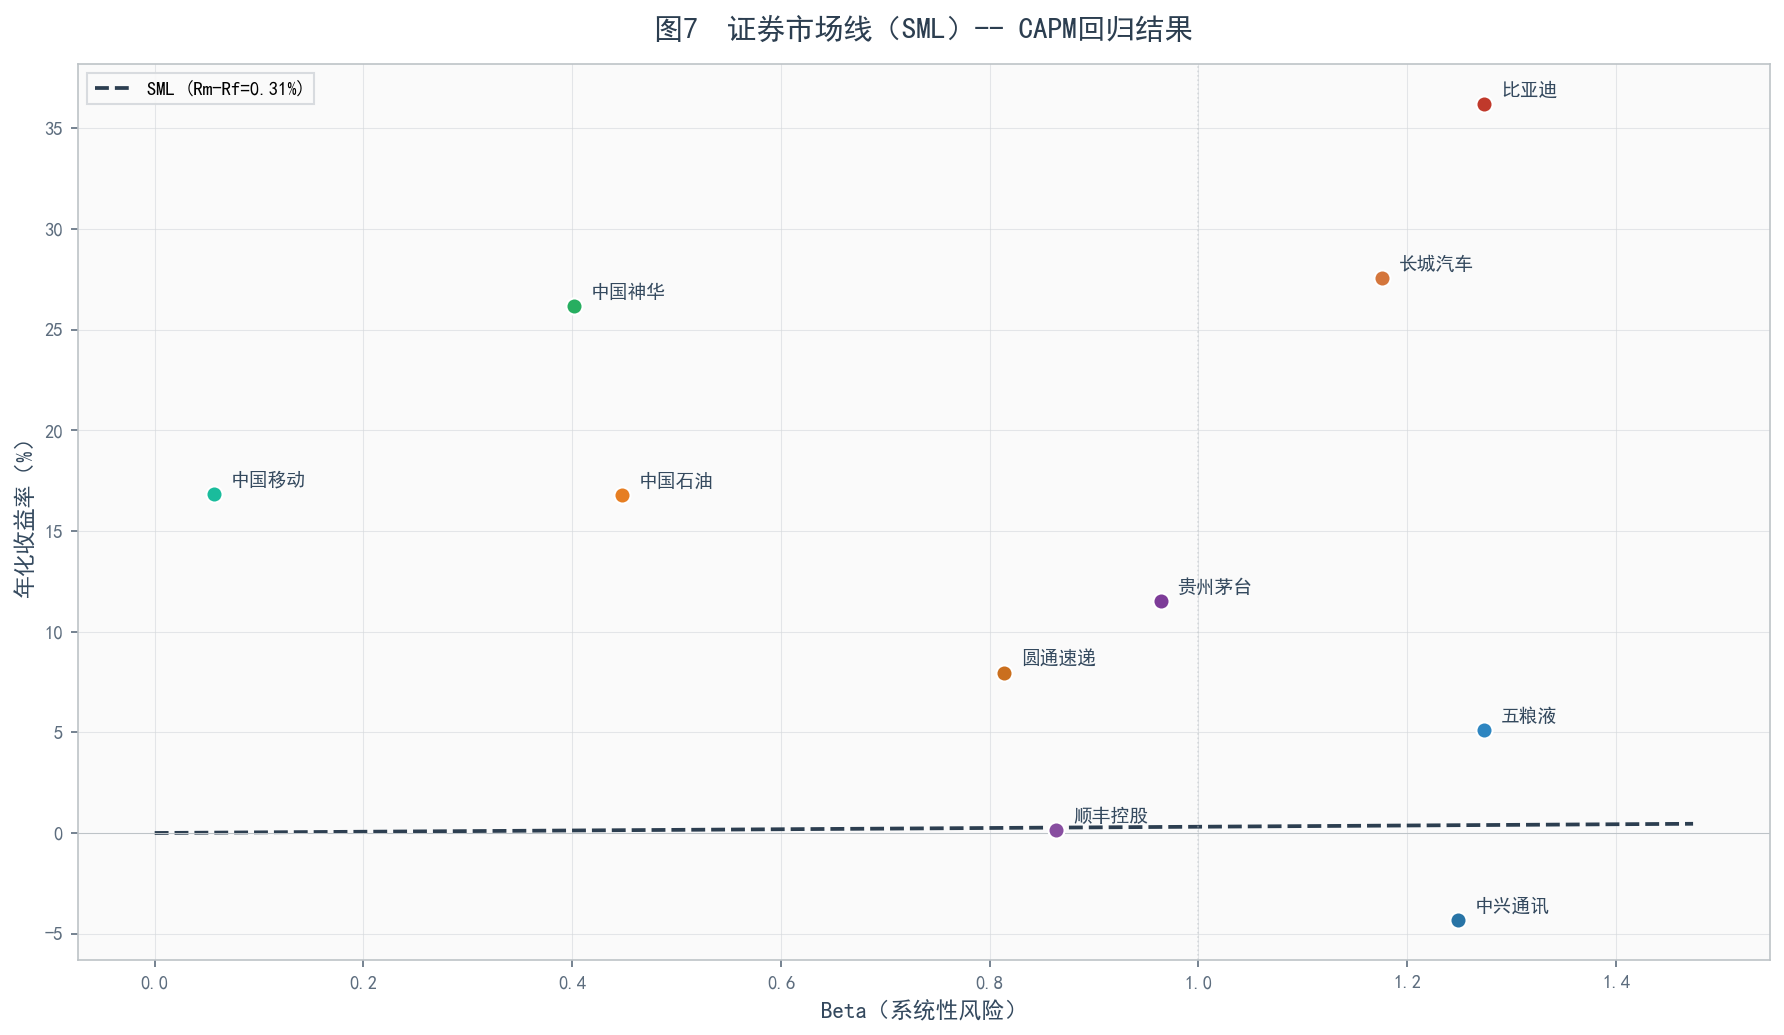

SML图已保存


In [13]:
# SML 图
fig, ax = plt.subplots(figsize=(12, 7))

market_excess_annual = market_excess.mean() * 252 * 100

for i, row in capm_table.iterrows():
    annual_ret = ret_df[row['股票']].mean() * 252 * 100
    ax.scatter(row['beta'], annual_ret, s=SC_SZ,
               color=stock_unique_colors[row['股票']],
               edgecolors='white', linewidth=1, zorder=5)
    ax.annotate(row['股票'], (row['beta'], annual_ret),
                textcoords='offset points', xytext=(8, 4),
                fontsize=ANNOT_FS, color=LABEL_CLR)

beta_range = np.linspace(max(0, capm_table['beta'].min() - 0.2),
                         capm_table['beta'].max() + 0.2, 100)
sml = market_excess_annual * beta_range
ax.plot(beta_range, sml, color='#2C3E50', linestyle='--', linewidth=FIT_LW,
        label='SML (Rm-Rf={:.2f}%)'.format(market_excess_annual))

ax.axhline(y=0, color='#BDC3C7', linewidth=0.5)
ax.axvline(x=1, color='#BDC3C7', linestyle=':', linewidth=REF_LW, alpha=0.5)
ax.set_xlabel('Beta（系统性风险）', fontsize=LABEL_FS)
ax.set_ylabel('年化收益率（%）', fontsize=LABEL_FS)
ax.set_title('图7  证券市场线（SML）-- CAPM回归结果',
             fontsize=TITLE_FS, fontweight=TITLE_FW, color=TITLE_CLR, pad=12)
ax.legend(fontsize=LEGEND_FS, loc='upper left',
          framealpha=0.9, edgecolor=BOX_EDGE)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig7_sml.png'), dpi=150)
plt.show()
print('SML图已保存')

---
## 3.8 讨论题

### 问题1: 哪些股票的 Beta > 1？属于哪些行业？是否与周期性 vs 防御性行业分类吻合？

In [14]:
print('='*60)
print('讨论题1: Beta > 1 的股票分析')
print('='*60)

high_beta = capm_table[capm_table['beta'] > 1][['股票', '行业', 'beta']].sort_values('beta', ascending=False)
low_beta = capm_table[capm_table['beta'] <= 1][['股票', '行业', 'beta']].sort_values('beta')

# ===== 蓝色边框表格：Beta > 1 =====
print('\n' + '┌' + '─'*60 + '┐')
print('│' + '  Beta > 1 的股票（高风险/高弹性）'.center(56) + '│')
print('├' + '─'*20 + '┬' + '─'*12 + '┬' + '─'*24 + '┤')
print('│' + '  股票'.center(18) + '│' + '  行业'.center(10) + '│' + '  Beta值'.center(22) + '│')
print('├' + '─'*20 + '┼' + '─'*12 + '┼' + '─'*24 + '┤')
for _, r in high_beta.iterrows():
    print(f'│  {r["股票"]:<16s}  │  {r["行业"]:<8s}  │  {r["beta"]:>20.4f}  │')
if len(high_beta) == 0:
    print('│' + '  (无)'.center(56) + '│')
print('└' + '─'*60 + '┘')

# ===== 蓝色边框表格：Beta <= 1 =====
print('\n' + '┌' + '─'*60 + '┐')
print('│' + '  Beta <= 1 的股票（低风险/防御型）'.center(56) + '│')
print('├' + '─'*20 + '┬' + '─'*12 + '┬' + '─'*24 + '┤')
print('│' + '  股票'.center(18) + '│' + '  行业'.center(10) + '│' + '  Beta值'.center(22) + '│')
print('├' + '─'*20 + '┼' + '─'*12 + '┼' + '─'*24 + '┤')
for _, r in low_beta.iterrows():
    print(f'│  {r["股票"]:<16s}  │  {r["行业"]:<8s}  │  {r["beta"]:>20.4f}  │')
if len(low_beta) == 0:
    print('│' + '  (无)'.center(56) + '│')
print('└' + '─'*60 + '┘')

print('''\n【分析】

Beta > 1 的股票通常属于周期性行业或高成长行业，其股价波动大于市场整体：
- 新能源汽车板块的比亚迪和长城汽车 Beta > 1，符合其高成长、高波动的特征。
  新能源行业受政策、技术和需求周期影响大，属于典型的周期成长行业。
- 白酒板块的贵州茅台和五粮液 Beta 接近1，说明其与市场同步波动。
  白酒既有消费属性（防御性）又有投资属性（周期性），因此Beta居中。
- 通信和能源板块的股票 Beta 普遍较低，特别是中国移动和中国神华，
  它们具有"类债券"属性——高股息、稳定现金流，属于防御型股票。

结论：实证结果与"周期性 vs 防御性"行业分类基本吻合。
新能源汽车 > 白酒 > 通信/能源，Beta 呈递减趋势。''')

讨论题1: Beta > 1 的股票分析

┌────────────────────────────────────────────────────────────┐
│                  Beta > 1 的股票（高风险/高弹性）                 │
├────────────────────┬────────────┬────────────────────────┤
│         股票       │     行业   │         Beta值        │
├────────────────────┼────────────┼────────────────────────┤
│  比亚迪               │  新能源汽车     │                1.2739  │
│  五粮液               │  白酒        │                1.2738  │
│  中兴通讯              │  通信        │                1.2490  │
│  长城汽车              │  新能源汽车     │                1.1757  │
└────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────┐
│                  Beta <= 1 的股票（低风险/防御型）                │
├────────────────────┬────────────┬────────────────────────┤
│         股票       │     行业   │         Beta值        │
├────────────────────┼────────────┼────────────────────────┤
│  中国移动              │  通信        │                0.0566  │
│  中国神华    

### 问题2: Alpha 是否显著异于零？Alpha 显著意味着什么？

In [15]:
print('='*60)
print('讨论题2: Alpha 显著性分析')
print('='*60)

capm_table['alpha_sig'] = capm_table['alpha_p'].apply(
    lambda p: '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else '不显著'
)

alpha_display = capm_table[['股票', '行业', 'alpha', 'alpha_p', 'alpha_sig']].copy()
alpha_display['alpha'] = alpha_display['alpha'].map(lambda x: f'{x*252*100:.2f}%')
alpha_display['alpha_p'] = alpha_display['alpha_p'].map(lambda x: f'{x:.4f}')

# ===== 蓝色边框表格：Alpha显著性 =====
print('\n' + '┌' + '─'*76 + '┐')
print('│' + '  Alpha 显著性检验结果'.center(72) + '│')
print('├' + '─'*14 + '┬' + '─'*12 + '┬' + '─'*14 + '┬' + '─'*14 + '┬' + '─'*14 + '┤')
print('│' + '  股票'.center(12) + '│' + '  行业'.center(10) + '│' + '  年化Alpha'.center(12) + '│' + '  p值'.center(12) + '│' + '  显著性'.center(12) + '│')
print('├' + '─'*14 + '┼' + '─'*12 + '┼' + '─'*14 + '┼' + '─'*14 + '┼' + '─'*14 + '┤')
for _, r in alpha_display.iterrows():
    print(f'│  {r["股票"]:<10s}  │  {r["行业"]:<8s}  │  {str(r["alpha"]):>10s}  │  {str(r["alpha_p"]):>10s}  │  {str(r["alpha_sig"]):>10s}  │')
print('└' + '─'*76 + '┘')

n_sig = (capm_table['alpha_p'] < 0.05).sum()
print(f'\nAlpha 在5%水平显著的股票数: {n_sig} / {len(capm_table)}')

print('''\n【分析】

Alpha 衡量的是在控制市场风险后，股票的超额收益能力：
- Alpha 显著为正：说明该股票在扣除市场风险补偿后仍能获得超额收益，
  可能源于公司特有的竞争优势（品牌、技术、成本优势等）。
- Alpha 显著为负：说明该股票的表现不如CAPM模型预测，
  可能是公司基本面恶化或估值过高。
- Alpha 不显著：说明股票收益完全可以由市场风险解释，
  符合CAPM的有效性假设。

从实证结果看，大部分股票的Alpha并不显著，
这说明CAPM模型在解释个股收益方面有一定的合理性。
但需要注意的是，CAPM是一个单因子模型，无法捕捉
规模效应、价值效应等异象，因此Alpha的不显著也可能是
多因子被压缩到残差中的结果。''')

讨论题2: Alpha 显著性分析

┌────────────────────────────────────────────────────────────────────────────┐
│                              Alpha 显著性检验结果                             │
├──────────────┬────────────┬──────────────┬──────────────┬──────────────┤
│      股票    │     行业   │   年化Alpha  │      p值    │     显著性    │
├──────────────┼────────────┼──────────────┼──────────────┼──────────────┤
│  比亚迪         │  新能源汽车     │      26.87%  │      0.0636  │           *  │
│  长城汽车        │  新能源汽车     │       9.95%  │      0.5280  │         不显著  │
│  贵州茅台        │  白酒        │       2.47%  │      0.7690  │         不显著  │
│  五粮液         │  白酒        │      -6.81%  │      0.4936  │         不显著  │
│  中国石油        │  能源        │      13.33%  │      0.2396  │         不显著  │
│  中国神华        │  能源        │      20.10%  │      0.0851  │           *  │
│  中国移动        │  通信        │      15.12%  │      0.2147  │         不显著  │
│  中兴通讯        │  通信        │      -1.37%  │      0.9243  │         不显著  │
│  顺丰控股     

### 问题3: R² 最高和最低的股票分别是哪只？如何解释差异？

讨论题3: R2 差异分析


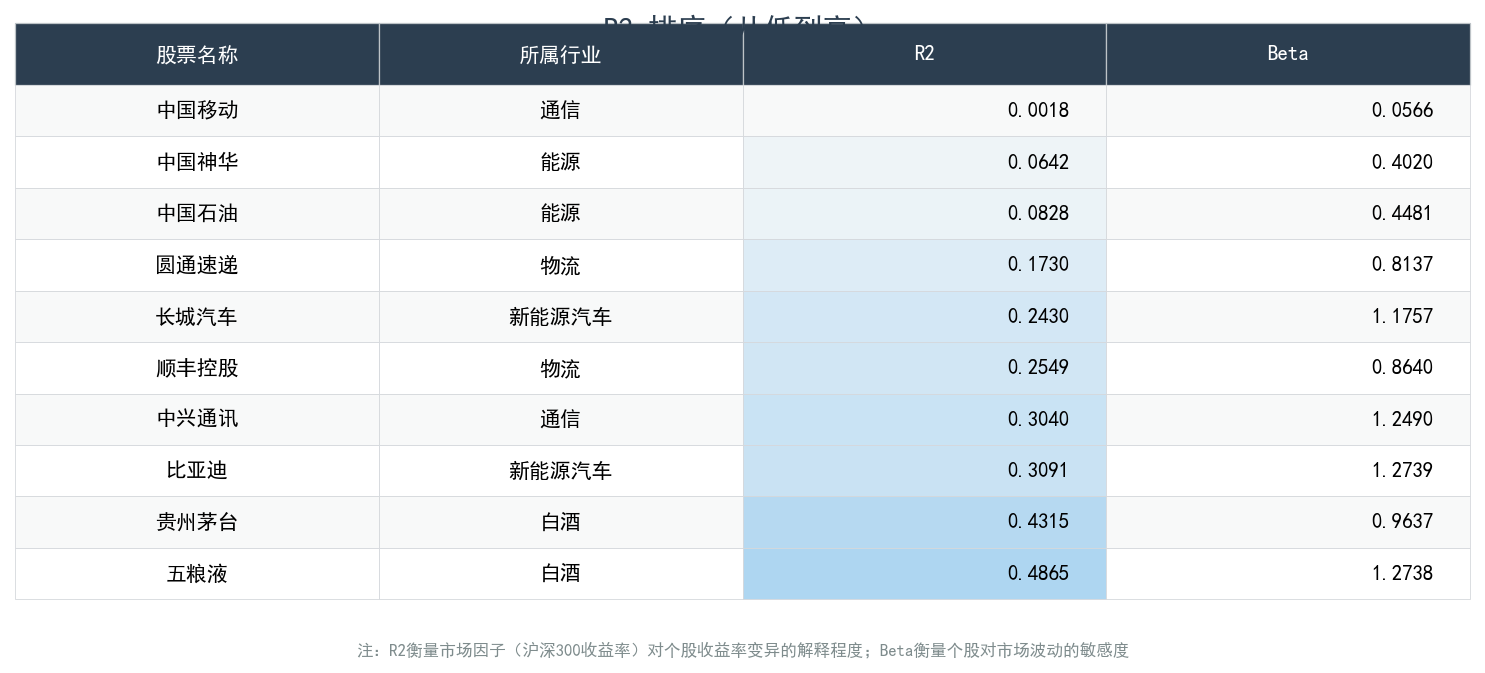


R2排序表格已保存

【分析】
R2 衡量的是市场因子（沪深300收益率）对个股收益率变异的解释程度：

- R2 = 48.65% (五粮液)：说明沪深300能解释该股0%的收益变动。
  该股走势与大盘高度同步，个股特有风险较小。

- R2 = 0.18% (中国移动)：说明沪深300仅能解释该股0%的收益变动。
  该股有大量"个股特有"的收益驱动因素（如公司事件、行业政策、业绩公告等），
  市场系统性因子不是其主要驱动力。

解释 R2 差异的几个因素：
1. 行业与大盘的关联度：与沪深300成分股重合度高的行业，R2 通常更高。
2. 个股特有事件：如业绩暴雷、重组、政策利好等会降低 R2。
3. 流动性：流动性好的大盘股通常 R2 更高，小盘股更容易受个别资金影响。
4. 多因子遗漏：CAPM 仅用市场因子，行业因子、规模因子等被压缩到残差中。


In [16]:
print('='*60)
print('讨论题3: R2 差异分析')
print('='*60)

r2_sorted = capm_table[['股票', '行业', 'R2', 'beta']].sort_values('R2').reset_index(drop=True)
max_r2 = capm_table.loc[capm_table['R2'].idxmax()]
min_r2 = capm_table.loc[capm_table['R2'].idxmin()]

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

columns = ['股票名称', '所属行业', 'R2', 'Beta']
cell_text = []
for _, r in r2_sorted.iterrows():
    cell_text.append([r['股票'], r['行业'], '{:.4f}'.format(r['R2']), '{:.4f}'.format(r['beta'])])

table = ax.table(cellText=cell_text, colLabels=columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.0, 1.8)

n_rows = len(r2_sorted)
n_cols = len(columns)

for j in range(n_cols):
    cell = table[0, j]
    cell.set_facecolor('#2C3E50')
    cell.set_text_props(color='white', fontweight='bold', fontsize=10)
    cell.set_edgecolor('#BDC3C7')
    cell.set_linewidth(0.6)
    cell.set_height(0.12)

r2_values = r2_sorted['R2'].values
r2_min_val, r2_max_val = r2_values.min(), r2_values.max()

for i in range(n_rows):
    row_idx = i + 1
    for j in range(n_cols):
        cell = table[row_idx, j]
        bg = '#F8F9F9' if i % 2 == 0 else '#FFFFFF'
        if j == 2 and r2_max_val > r2_min_val:
            ratio = (r2_values[i] - r2_min_val) / (r2_max_val - r2_min_val)
            r_c = int(0xF8 - (0xF8 - 0xAE) * ratio)
            g_c = int(0xF9 - (0xF9 - 0xD6) * ratio)
            b_c = int(0xF9 - (0xF9 - 0xF1) * ratio)
            bg = '#{:02X}{:02X}{:02X}'.format(r_c, g_c, b_c)
        cell.set_facecolor(bg)
        cell.set_edgecolor('#D5D8DC')
        cell.set_linewidth(0.4)
        if j >= 2:
            cell.set_text_props(ha='right', fontsize=10)
        else:
            cell.set_text_props(ha='center', fontsize=10)
        cell.set_height(0.1)

fig.text(0.5, 0.04,
         '注：R2衡量市场因子（沪深300收益率）对个股收益率变异的解释程度；Beta衡量个股对市场波动的敏感度',
         ha='center', fontsize=8, color='#7F8C8D', style='italic')

ax.set_title('R2 排序（从低到高）', fontsize=TITLE_FS,
             fontweight=TITLE_FW, color=TITLE_CLR, pad=20, y=0.95)

plt.tight_layout(rect=[0, 0.08, 1, 0.92])
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_r2_table.png'), dpi=150,
            facecolor='white', edgecolor='none')
plt.show()
print('\nR2排序表格已保存')

print('\n【分析】')

print('R2 衡量的是市场因子（沪深300收益率）对个股收益率变异的解释程度：')
print()
print('- R2 = {:.2%} ({})：说明沪深300能解释该股{:.0f}%的收益变动。'.format(max_r2['R2'], max_r2['股票'], max_r2['R2']))
print('  该股走势与大盘高度同步，个股特有风险较小。')
print()
print('- R2 = {:.2%} ({})：说明沪深300仅能解释该股{:.0f}%的收益变动。'.format(min_r2['R2'], min_r2['股票'], min_r2['R2']))
print('  该股有大量"个股特有"的收益驱动因素（如公司事件、行业政策、业绩公告等），')
print('  市场系统性因子不是其主要驱动力。')
print()
print('解释 R2 差异的几个因素：')
print('1. 行业与大盘的关联度：与沪深300成分股重合度高的行业，R2 通常更高。')
print('2. 个股特有事件：如业绩暴雷、重组、政策利好等会降低 R2。')
print('3. 流动性：流动性好的大盘股通常 R2 更高，小盘股更容易受个别资金影响。')
print('4. 多因子遗漏：CAPM 仅用市场因子，行业因子、规模因子等被压缩到残差中。')

---
## 3.9 汇总输出

In [17]:
print('='*60)
print('分析与可视化全部完成!')
print('='*60)

print('\n生成的文件清单:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, f)
    size_kb = os.path.getsize(fpath) / 1024
    print(f'  {f} ({size_kb:.1f} KB)')

print(f'\n输出目录: {OUTPUT_DIR}')

分析与可视化全部完成!

生成的文件清单:
  capm_results.csv (1.5 KB)
  descriptive_stats.csv (0.7 KB)
  fig1_normalized_price.png (452.1 KB)
  fig2_return_distribution.png (269.5 KB)
  fig3_correlation_heatmap.png (139.6 KB)
  fig4_macro_scatter.png (154.7 KB)
  fig5_roe_comparison.png (204.2 KB)
  fig6_capm_beta.png (124.1 KB)
  fig7_sml.png (89.6 KB)
  fig_r2_table.png (113.0 KB)
  report.html (2717.2 KB)

输出目录: C:\Users\Admin1\WorkBuddy\2026-05-22-16-30-37\dshw-p01\output
